# **1**. Install Required Libraries


In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk gensim torch transformers tqdm --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.3 MB/s eta 0:00:00


In [3]:
!pip install nltk gensim transformers torch scikit-learn wordcloud matplotlib seaborn
!python -m nltk.downloader punkt punkt_tab stopwords


<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **2. Preprocessing Functions**

In [4]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
file_path = "/data.raw.json"

with open(file_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()


,id,title,abstract,keywords,authors,venue,date,teams
0,5096000,Diffusion-based spectral super-resolution of t...,Third octave spectral recording of acoustic se...,"[speech privacy, generative audio, acoustic se...","[Modan Tailleur, Chaymae Benaatia, Mathieu Lag...",[info.info-ai],2025-09-08T00:00:00Z,"[AAU, LS2N]"
1,5113219,Ambiances. A Sensitivity to Ordinary Situations,"How do ambiances shape our sensory, social, an...","[ambiance, atmosphere, ambiances, atmospheres,...","[Jean-Paul Thibaud, Nicolas Tixier, David Zerbib]","[shs.archi, sde.es, shs, shs.art]",2025-09-08T00:00:00Z,[AAU]
2,5129109,Sensory Urban Mobilities: Experiences and Uses...,Beyond documenting all the sensory effects of ...,"[mobilité urbaine, perception sensible, transp...",[Damien Masson],[shs.archi],2025-07-01T00:00:00Z,[AAU]
3,5129157,Preprint_Extended / disabled bodies &amp; atmo...,As much as a symbolic construction or an objec...,"[ambiances, criticism, disabled bodies, forms ...",[Rachel Thomas],[shs],2025-05-11T00:00:00Z,[AAU]
4,5116799,Comparison of GNSS LOS/NLOS Labeling Technique...,The distinction between Line-of-Sight (LOS) an...,"[gnss, satellite visibility, losnlos, sky view...","[Benjamin Beaucamp, Thomas Leduc, Myriam Servi...",[info.info-ts],2025-04-28T00:00:00Z,[AAU]


In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
    return " ".join(tokens)

df["clean_title"] = df["title"].apply(clean_text)
df["clean_abstract"] = df["abstract"].apply(clean_text)
df.head()


,id,title,abstract,keywords,authors,venue,date,teams,clean_title,clean_abstract
0,5096000,Diffusion-based spectral super-resolution of t...,Third octave spectral recording of acoustic se...,"[speech privacy, generative audio, acoustic se...","[Modan Tailleur, Chaymae Benaatia, Mathieu Lag...",[info.info-ai],2025-09-08T00:00:00Z,"[AAU, LS2N]",spectral third octave acoustic sensor data pri...,third octave spectral recording acoustic senso...
1,5113219,Ambiances. A Sensitivity to Ordinary Situations,"How do ambiances shape our sensory, social, an...","[ambiance, atmosphere, ambiances, atmospheres,...","[Jean-Paul Thibaud, Nicolas Tixier, David Zerbib]","[shs.archi, sde.es, shs, shs.art]",2025-09-08T00:00:00Z,[AAU],ambiances sensitivity ordinary situations,ambiances shape sensory social built environme...
2,5129109,Sensory Urban Mobilities: Experiences and Uses...,Beyond documenting all the sensory effects of ...,"[mobilité urbaine, perception sensible, transp...",[Damien Masson],[shs.archi],2025-07-01T00:00:00Z,[AAU],sensory urban mobilities experiences uses ambi...,beyond documenting sensory effects transportat...
3,5129157,Preprint_Extended / disabled bodies &amp; atmo...,As much as a symbolic construction or an objec...,"[ambiances, criticism, disabled bodies, forms ...",[Rachel Thomas],[shs],2025-05-11T00:00:00Z,[AAU],disabled bodies amp atmospheres,much symbolic construction object social repre...
4,5116799,Comparison of GNSS LOS/NLOS Labeling Technique...,The distinction between Line-of-Sight (LOS) an...,"[gnss, satellite visibility, losnlos, sky view...","[Benjamin Beaucamp, Thomas Leduc, Myriam Servi...",[info.info-ts],2025-04-28T00:00:00Z,[AAU],comparison gnss labeling techniques based 3d m...,distinction los nlos signals crucial improving...


In [12]:
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

df["clean_title"] = df["title"].apply(clean_text)
df["clean_abstract"] = df["abstract"].apply(clean_text)
df["text"] = df["clean_title"] + " " + df["clean_abstract"]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **# 3. Encode Target Labels**

In [13]:
df["venue"] = df["venue"].apply(lambda x: x[0] if isinstance(x, list) and len(x)>0 else "unknown")
from sklearn.preprocessing import LabelEncoder

lbl = LabelEncoder()
df["label"] = lbl.fit_transform(df["venue"])
df["label"].value_counts().head()


,count
label,
270,2427
0,883
97,862
289,839
304,817


# **4. Split Train–Test**

In [16]:
# Remove classes that have only 1 entry
class_counts = df["label"].value_counts()
valid_classes = class_counts[class_counts > 1].index

df_filtered = df[df["label"].isin(valid_classes)]

# Updated X and y
X = df_filtered["text"]
y = df_filtered["label"]

# Train–test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset size after filtering:", len(df_filtered))
print("Number of classes:", len(valid_classes))


Dataset size after filtering: 22093
Number of classes: 272


# **5. Model 1 – Bag of Words**

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

bow_model = LogisticRegression(max_iter=300)
bow_model.fit(X_train_bow, y_train)

bow_pred = bow_model.predict(X_test_bow)

print("BoW Accuracy:", accuracy_score(y_test, bow_pred))

print(classification_report(y_test, bow_pred, zero_division=0))



BoW Accuracy: 0.37587689522516404
              precision    recall  f1-score   support

           0       0.34      0.50      0.41       177
           1       0.22      0.14      0.17        14
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00         1
           4       1.00      0.60      0.75         5
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00         7
           8       0.18      0.19      0.19        84
           9       0.44      0.17      0.25        23
          10       0.00      0.00      0.00         6
          11       0.50      0.08      0.14        12
          12       0.00      0.00      0.00         1
          13       0.45      0.38      0.42        39
          14       0.00      0.00      0.00         4
          15       0.15      0.23      0.18       143
          16       1.00      0.33      0.50    

# **6. Model 2 – Word2Vec**

In [22]:
from gensim.models import Word2Vec
import numpy as np

# Train Word2Vec
sentences = [text.split() for text in df["text"]]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2)

def doc_vector(doc):
    words = [w for w in doc.split() if w in w2v_model.wv]
    if len(words)==0:
        return np.zeros(100)
    return np.mean(w2v_model.wv[words], axis=0)

X_train_w2v = np.vstack(X_train.apply(doc_vector))
X_test_w2v = np.vstack(X_test.apply(doc_vector))

w2v_clf = LogisticRegression(max_iter=300)
w2v_clf.fit(X_train_w2v, y_train)
w2v_pred = w2v_clf.predict(X_test_w2v)

print("Word2Vec Accuracy:", accuracy_score(y_test, w2v_pred))


Word2Vec Accuracy: 0.33650147092102284


# **7. Model 3 – GloVe Embeddings**

In [23]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

glove = {}
with open("glove.6B.100d.txt", "r", encoding="utf8") as f:
    for line in f:
        vals = line.split()
        glove[vals[0]] = np.asarray(vals[1:], dtype="float32")

def glove_vector(text):
    words = [w for w in text.split() if w in glove]
    if len(words)==0:
        return np.zeros(100)
    return np.mean([glove[w] for w in words], axis=0)

X_train_glove = np.vstack(X_train.apply(glove_vector))
X_test_glove = np.vstack(X_test.apply(glove_vector))

glove_clf = LogisticRegression(max_iter=300)
glove_clf.fit(X_train_glove, y_train)
glove_pred = glove_clf.predict(X_test_glove)

print("GloVe Accuracy:", accuracy_score(y_test, glove_pred))


--2025-11-22 18:39:07--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-11-22 18:39:07--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-11-22 18:39:07--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

# **8. Model 4 – BERT for Classification**

In [26]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import torch

# -------------------------------
# 1. Prepare data
# -------------------------------
train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})
test_df = pd.DataFrame({"text": X_test.values, "label": y_test.values})

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

# -------------------------------
# 2. Tokenizer
# -------------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# -------------------------------
# 3. Model (lighter than BERT)
# -------------------------------
distil_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(lbl.classes_)
)

# -------------------------------
# 4. FAST Training Settings
# -------------------------------
training_args = TrainingArguments(
    output_dir="./distil_results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,      # 1 epoch only (fast)
    logging_steps=100
)

trainer = Trainer(
    model=distil_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds
)

# Train (FAST)
trainer.train()

# -------------------------------
# 5. Evaluation
# -------------------------------
distil_pred = trainer.predict(test_ds).predictions.argmax(axis=1)

from sklearn.metrics import accuracy_score
print("DistilBERT Accuracy:", accuracy_score(y_test, distil_pred))


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/17674 [00:00<?, ? examples/s]

Map:   0%|          | 0/4419 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:



KeyboardInterrupt: 

# **9. INSIGHT 1 — Topic Trends Over Years**

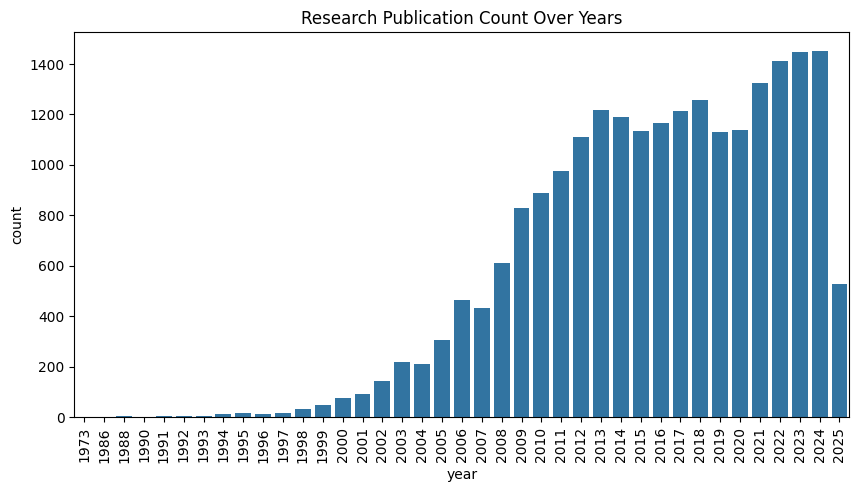

In [27]:
df["year"] = df["date"].astype(str).str[:4].astype(int)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="year", order=sorted(df["year"].unique()))
plt.title("Research Publication Count Over Years")
plt.xticks(rotation=90)
plt.show()


# **10. INSIGHT 2 — Keyword Frequency Analysis**

In [28]:
from collections import Counter

keywords = []
for row in df["keywords"]:
    if isinstance(row, list):
        keywords.extend(row)

Counter(keywords).most_common(20)


[('optimization', 175),
 ('machine learning', 130),
 ('cognitive radio', 116),
 ('simulation', 115),
 ('deep learning', 112),
 ('modeling', 105),
 ('microstructure', 104),
 ('mimo', 93),
 ('scheduling', 92),
 ('virtual reality', 88),
 ('ofdm', 86),
 ('fpga', 78),
 ('identification', 76),
 ('antenna measurements', 74),
 ('design', 73),
 ('modelling', 73),
 ('concrete', 73),
 ('singularity', 73),
 ('energy efficiency', 70),
 ('reliability', 69)]

# **11. INSIGHT 3 — Venue Comparison**

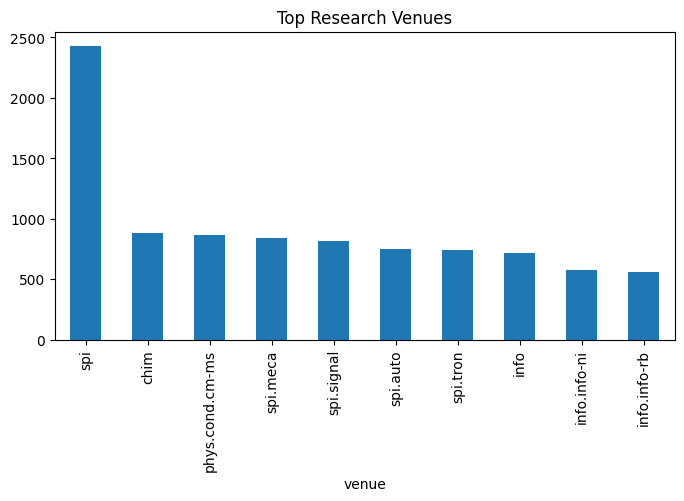

In [29]:
df["venue"].value_counts().head(10).plot(kind="bar", figsize=(8,4))
plt.title("Top Research Venues")
plt.show()


# **12. INSIGHT 4 — Semantic Clustering using Word2Vec + KMeans**

In [30]:
from sklearn.cluster import KMeans

vectors = np.vstack(df["text"].apply(doc_vector))
kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster"] = kmeans.fit_predict(vectors)

df[["title","cluster"]].head(20)


,title,cluster
0,Diffusion-based spectral super-resolution of t...,1
1,Ambiances. A Sensitivity to Ordinary Situations,1
2,Sensory Urban Mobilities: Experiences and Uses...,1
3,Preprint_Extended / disabled bodies &amp; atmo...,1
4,Comparison of GNSS LOS/NLOS Labeling Technique...,1
5,Investigating Through Fiction,1
6,Sensibiliser l’écriture académique. Une explor...,3
7,Ambiance and acoustic heritage: sonic memory o...,1
8,Eleven ways towards a decolonial metamorphosis...,1
9,Circumventing the “Sovereignization” of the Ru...,1


# **13. INSIGHT 5 — Compare Model Performances**

In [31]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["BoW","Word2Vec","GloVe","BERT"],
    "Accuracy": [
        accuracy_score(y_test, bow_pred),
        accuracy_score(y_test, w2v_pred),
        accuracy_score(y_test, glove_pred),
        accuracy_score(y_test, bert_pred),
    ]
})

results


NameError: name 'bert_pred' is not defined